# Training and Data Analysis without Lagrangian

## Basic Equation

$$ \dot{x} = Ax + Bu \tag{1}$$

$\dot{x}$ (x-dot): The State Derivative Vector. This represents how fast the system is currently changing. If your system is a moving vehicle, this contains your current acceleration and jerk.

$x$: The State Vector. This represents the current "status" of the system at this exact millisecond. For a vehicle, this contains the current position and velocity.

$u$: The Input Vector. This represents the control commands you are feeding into the system (e.g., motor voltages, steering angles, or thrusts).

$A$: The System Matrix (or Dynamics Matrix). This defines how the system behaves "naturally" when you aren't touching the controls. It models internal physics like friction, gravity, and momentum. It dictates how the current state ($x$) causes future changes ($\dot{x}$).

$B$: The Input Matrix (or Control Matrix). This defines exactly how your control commands ($u$) physically translate into changes in the system. It scales your inputs into the mathematical realm of the state derivative.


## Mellinger's Equation

$$
\begin{bmatrix}
F_{B} & M_{xB} & M_{yB} & M_{zB}
\end{bmatrix} ^ T

= Au
\tag{2}
$$

since we need to calculate the Thrust $u$. We can rearrage the above equation to:

$$
\begin{bmatrix}
F_{B} & M_{xB} & M_{yB} & M_{zB}
\end{bmatrix} ^ T

A^{-1} = u

\tag{3}
$$

where $A$ is the dynamics of the system mentioned in (1)

## PINNs Dynamics

Referring to the equation (3), since there is the static payload the $A$ will be:

$$ A_{final} = A_{B} + A_{payload} \tag{4}$$

If we put the numbers:

$$
    A_{B} =
    \begin{bmatrix}
        1.0 & 1.0 & 1.0 & 1.0 \\
        0.5 & -0.5 &  0.5 & -0.5 \\
        -0.5 & -0.5 &  0.5 &  0.5 \\
        1.0 & -1.0 & -1.0 & 1.0 \\
    \end{bmatrix}
$$

What the PINN should do is guess the new $A_{final}$ based on the current dynamics of the system.

How?

The PINNs must guess:
1. Payload offset -> calculate the new CoG -> then calculate the new $A_{final}$ using get_allocation_matrix
2. Directly calculate the CoG -> then use get_allocation_matrix to get the new $A_{final}$

WE DO THE NUMBER 2!

Example value

`
payload shift [-0.1186087433259104, 0.06072794823588726, 0.05] new cog -0.015206249144347487 0.007785634389216315
`

## Doing Training



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import numpy as np
import torch.optim as optim
from IPython.display import clear_output
from tqdm.notebook import tqdm # Jupyter-friendly progress bar
from matplotlib.gridspec import GridSpec

# call the library
from pinn_cog_detection import PINNCoGDetection


In [3]:
df = pd.read_csv("hover_flight_data_1000ep.csv")
df.describe

<bound method NDFrame.describe of            time_t     pos_x     pos_y     pos_z      roll     pitch  \
0        0.000000 -0.000003 -0.000004  0.198750 -0.000666  0.000511   
1        0.004167 -0.000006 -0.000008  0.197784 -0.001205  0.000929   
2        0.008333 -0.000008 -0.000010  0.197047 -0.001645  0.001275   
3        0.012500 -0.000010 -0.000012  0.196496 -0.002009  0.001563   
4        0.016667 -0.000011 -0.000014  0.196096 -0.002315  0.001809   
...           ...       ...       ...       ...       ...       ...   
1952927  2.583333 -0.419879 -1.374518  1.213705 -0.062961  0.037843   
1952928  2.587500 -0.420277 -1.377459  1.216514 -0.063327  0.037867   
1952929  2.591667 -0.420669 -1.380387  1.219326 -0.063690  0.037889   
1952930  2.595833 -0.421054 -1.383304  1.222143 -0.064051  0.037909   
1952931  2.600000 -0.421432 -1.386208  1.224962 -0.064409  0.037926   

                  yaw  velocity_x  velocity_y  velocity_z  ...   thrust_1  \
0       -1.626435e-07   -0.000787   

In [3]:
df.count

<bound method DataFrame.count of           time_t     pos_x     pos_y     pos_z      roll     pitch  \
0       0.000000 -0.000002 -0.000001  0.198735 -0.000208  0.000244   
1       0.004167 -0.000003 -0.000002  0.197757 -0.000376  0.000443   
2       0.008333 -0.000004 -0.000003  0.197010 -0.000514  0.000607   
3       0.012500 -0.000005 -0.000004  0.196451 -0.000627  0.000744   
4       0.016667 -0.000005 -0.000004  0.196045 -0.000722  0.000861   
...          ...       ...       ...       ...       ...       ...   
182597  6.120833 -1.056788  1.050699  4.366501 -0.005032  0.059277   
182598  6.125000 -1.056009  1.051779  4.370103 -0.004800  0.058952   
182599  6.129167 -1.055220  1.052859  4.373703 -0.004569  0.058624   
182600  6.133333 -1.054421  1.053940  4.377300 -0.004337  0.058292   
182601  6.137500 -1.053613  1.055021  4.380894 -0.004105  0.057956   

                 yaw  velocity_x  velocity_y  velocity_z  ...   thrust_1  \
0      -2.418893e-08   -0.000375   -0.000320   -0.

## Data Loader

In [2]:
class DroneTelemetryDataset(Dataset):
    def __init__(self, csv_file):
        df = pd.read_csv(csv_file)
        df = df.dropna()

        # The 25 inputs exactly matching your row dictionary
        features = [
            'pos_x', 'pos_y', 'pos_z', 'roll', 'pitch', 'yaw',
            'velocity_x', 'velocity_y', 'velocity_z',
            'ang_vel_x', 'ang_vel_y', 'ang_vel_z',
            'target_pos_x', 'target_pos_y', 'target_pos_z', 'target_yaw',
            'target_vel_x', 'target_vel_y', 'target_vel_z',
            'target_ang_vel_x', 'target_ang_vel_y', 'target_ang_vel_z',
            'target_acc_x', 'target_acc_y', 'target_acc_z'
        ]
        self.nn_inputs = df[features].values
        
        # Physics inputs needed strictly for the Loss Function
        self.applied_thrusts = df[['thrust_1', 'thrust_2', 'thrust_3', 'thrust_4']].values
        self.actual_wrench = df[['wrench_thrust', 'wrench_roll', 'wrench_pitch', 'wrench_yaw']].values
        
        # Ground truth labels (ONLY for tracking validation accuracy)
        self.true_cog = df[['true_cog_x', 'true_cog_y']].values

        # Convert to PyTorch tensors
        self.nn_inputs = torch.FloatTensor(self.nn_inputs)
        self.applied_thrusts = torch.FloatTensor(self.applied_thrusts)
        self.actual_wrench = torch.FloatTensor(self.actual_wrench)
        self.true_cog = torch.FloatTensor(self.true_cog)

    def __len__(self):
        return len(self.nn_inputs)

    def __getitem__(self, idx):
        return self.nn_inputs[idx], self.applied_thrusts[idx], self.actual_wrench[idx], self.true_cog[idx]

## Training Loop

### Training Using Mellinger Controller

In [3]:
def live_plot(history_loss, history_val, current_epoch, epochs):
    clear_output(wait=True)
    plt.figure(figsize=(12, 5))

    # Graph 1: Physics Loss
    plt.subplot(1, 2, 1)
    plt.plot(range(1, current_epoch + 1), history_loss, color='blue', linewidth=2)
    plt.title(f'PINN Physics Loss (Epoch {current_epoch}/{epochs})')
    plt.xlabel('Epoch')
    plt.ylabel('Residual Loss (MSE)')
    plt.xlim(1, epochs)
    plt.grid(True, linestyle='--', alpha=0.7)

    # Graph 2: Validation Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(range(1, current_epoch + 1), history_val, color='green', linewidth=2)
    plt.title('Validation Accuracy (Ground Truth)')
    plt.xlabel('Epoch')
    plt.ylabel('Error Distance (cm)')
    plt.xlim(1, epochs)
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

In [4]:
def physics_loss_function(predicted_cog, nominal_A, applied_thrusts, correct_wrench, batch_inputs):
    batch_size = predicted_cog.shape[0]
    cog_x = predicted_cog[:, 0]
    cog_y = predicted_cog[:, 1]

    # 1. Build the Matrix and predict the Wrench
    pos_y = nominal_A[1, :] 
    pos_x = -nominal_A[2, :]

    eff_x = pos_x.unsqueeze(0) - cog_x.unsqueeze(1)
    eff_y = pos_y.unsqueeze(0) - cog_y.unsqueeze(1)

    A_total = nominal_A.unsqueeze(0).repeat(batch_size, 1, 1).clone()
    A_total[:, 1, :] = eff_y     
    A_total[:, 2, :] = -eff_x    

    predicted_wrench = torch.bmm(A_total, applied_thrusts.unsqueeze(2)).squeeze(2)
    
    # 2. Calculate the base Physics Wrench Error for EACH item in the batch
    # (Notice we don't use nn.functional.mse_loss here, we do it manually to keep the batch dimension)
    base_physics_error = torch.mean((predicted_wrench - correct_wrench)**2, dim=1) # Shape: [batch_size]
    
    # ==========================================
    # 3. CALCULATE THE POSITION PENALTY WEIGHT
    # ==========================================
    # Extract positions from batch_inputs (Indices based on your 25-feature list)
    # pos_x, y, z are indices 1, 2, 3.
    # target_pos_x, y, z are indices 13, 14, 15.
    current_pos = batch_inputs[:, 1:4]
    target_pos = batch_inputs[:, 13:16]
    
    # Calculate the MSE between current and target position for each batch item
    position_mse = torch.mean((current_pos - target_pos)**2, dim=1) # Shape: [batch_size]
    
    # Create the weight. We add 1.0 so that even if position error is 0, 
    # the network still receives 1x the normal physics loss.
    # position_weight = 1.0 + position_mse
    
    # 4. Multiply the physics error by the position weight!
    weighted_loss = base_physics_error + position_mse
    
    # Return the average loss across the whole batch
    return weighted_loss.mean()

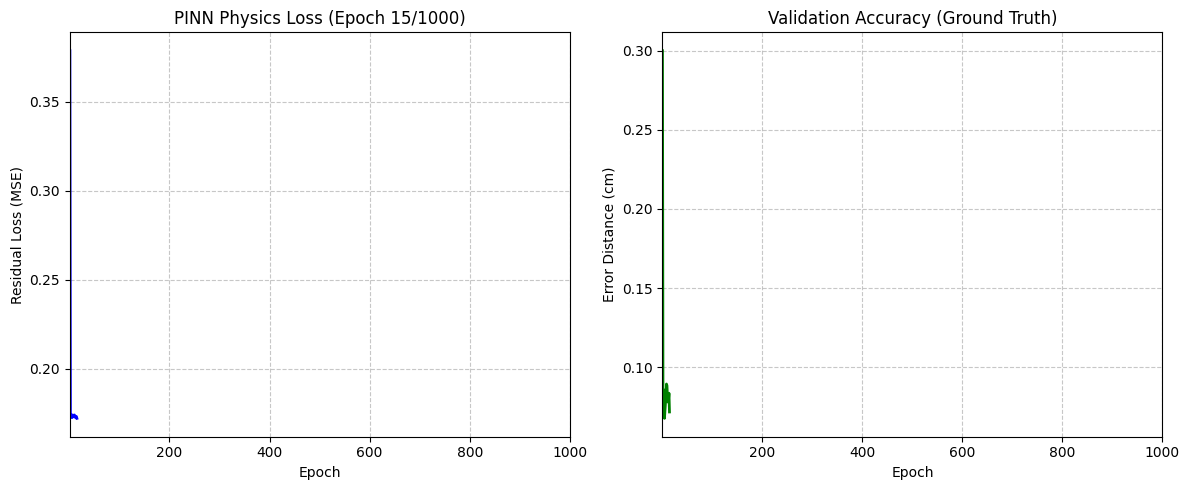

Epoch 015 | Physics Loss: 0.172126 | Validation Error: 0.07 cm


KeyboardInterrupt: 

In [5]:
# 1. Load Data
dataset = DroneTelemetryDataset('hover_flight_data_100ep.csv')
dataloader = DataLoader(dataset, batch_size=512, shuffle=True)

# Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on {device}...")

# 2. Init Model and Optimizer
model = PINNCoGDetection().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 3. Define the hardcoded Nominal A Matrix
A_nominal = torch.tensor([
    [ 1.0,  1.0,  1.0,  1.0],
    [ 0.5, -0.5,  0.5, -0.5],
    [-0.5, -0.5,  0.5,  0.5],
    [ 1.0, -1.0, -1.0,  1.0]
], dtype=torch.float32).to(device)

epochs = 1000
history_loss = []
history_val = []

# ==========================================
# THE TRAINING LOOP (Jupyter Optimized)
# ==========================================
# Use tqdm for a clean progress bar
for epoch in tqdm(range(epochs), desc="Training Epochs"):
    epoch_physics_loss = 0.0
    epoch_validation_error = 0.0
    
    for batch_inputs, batch_thrusts, batch_wrenches, batch_true_cog in dataloader:
        
        # Move data to GPU
        batch_inputs = batch_inputs.to(device)
        batch_thrusts = batch_thrusts.to(device)
        batch_wrenches = batch_wrenches.to(device)
        batch_true_cog = batch_true_cog.to(device)
        
        optimizer.zero_grad()
        
        # Forward Pass
        cog_guess = model(batch_inputs)
        
        # Physics Loss
        loss = physics_loss_function(cog_guess, A_nominal, batch_thrusts, batch_wrenches, batch_inputs)
        
        # Backprop
        loss.backward()
        optimizer.step()
        
        epoch_physics_loss += loss.item()
        
        # Validation Check
        with torch.no_grad():
            val_error = torch.mean(torch.abs(cog_guess - batch_true_cog))
            epoch_validation_error += val_error.item()

    # Calculate averages
    avg_loss = epoch_physics_loss / len(dataloader)
    avg_val = epoch_validation_error / len(dataloader)
    
    history_loss.append(avg_loss)
    history_val.append(avg_val * 100) # Convert meters to cm
    
    # Update the live plot every 5 epochs
    if (epoch + 1) % 5 == 0:
        live_plot(history_loss, history_val, epoch + 1, epochs)
        print(f"Epoch {epoch+1:03d} | Physics Loss: {avg_loss:.6f} | Validation Error: {avg_val * 100:.2f} cm")

# 4. Save the trained brain
torch.save(model.state_dict(), 'pinn_cog_weights.pth')
print("\nTraining Complete! Weights saved to 'pinn_cog_weights.pth'.")

# Final high-res save of the plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), history_loss, color='blue', linewidth=2)
plt.title('PINN Physics Loss (Unsupervised)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), history_val, color='green', linewidth=2)
plt.title('Validation Accuracy (Ground Truth)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('pinn_training_curve.png', dpi=300)
print("Training graph saved as 'pinn_training_curve.png'.")

### Training Using Geometric Controller

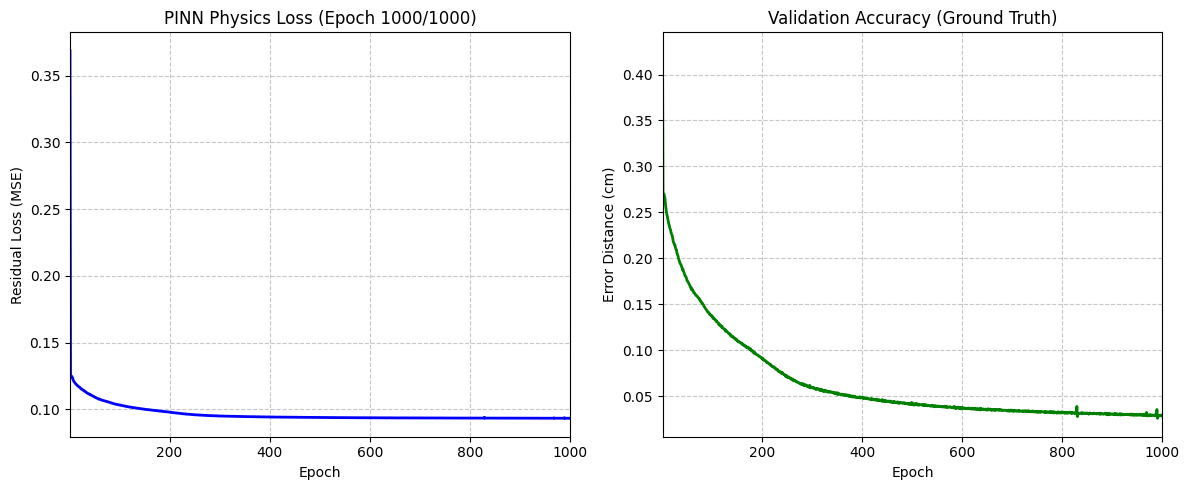

Epoch 1000 | Physics Loss: 0.093253 | Validation Error: 0.03 cm
Average loss RMSE : 0.09325250767812406
Validation RMSE : 0.028391618417721764

Training Complete! Weights saved to 'pinn_cog_weights.pth'.
Training graph saved as 'pinn_training_curve.png'.


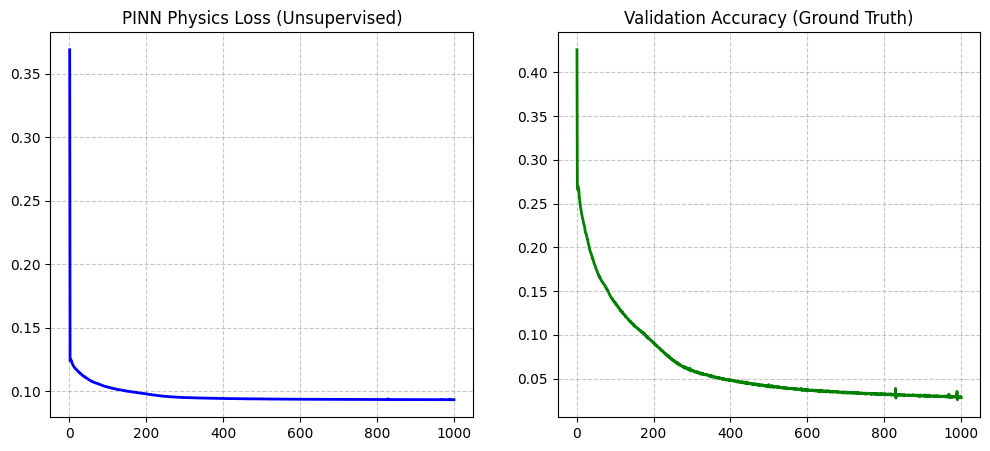

In [8]:
# 1. Load Data
dataset = DroneTelemetryDataset('hover_geo_flight_data_100ep_1.csv')
dataloader = DataLoader(dataset, batch_size=512, shuffle=True)

# Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on {device}...")

# 2. Init Model and Optimizer
model = PINNCoGDetection().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 3. Define the hardcoded Nominal A Matrix
A_nominal = torch.tensor([
    [ 1.0,  1.0,  1.0,  1.0],
    [ 0.5, -0.5,  0.5, -0.5],
    [-0.5, -0.5,  0.5,  0.5],
    [ 1.0, -1.0, -1.0,  1.0]
], dtype=torch.float32).to(device)

epochs = 1000
history_loss = []
history_val = []

# ==========================================
# THE TRAINING LOOP (Jupyter Optimized)
# ==========================================
# Use tqdm for a clean progress bar
for epoch in tqdm(range(epochs), desc="Training Epochs"):
    epoch_physics_loss = 0.0
    epoch_validation_error = 0.0
    
    for batch_inputs, batch_thrusts, batch_wrenches, batch_true_cog in dataloader:
        
        # Move data to GPU
        batch_inputs = batch_inputs.to(device)
        batch_thrusts = batch_thrusts.to(device)
        batch_wrenches = batch_wrenches.to(device)
        batch_true_cog = batch_true_cog.to(device)
        
        optimizer.zero_grad()
        
        # Forward Pass
        cog_guess = model(batch_inputs)
        
        # Physics Loss
        loss = physics_loss_function(cog_guess, A_nominal, batch_thrusts, batch_wrenches, batch_inputs)
        
        # Backprop
        loss.backward()
        optimizer.step()
        
        epoch_physics_loss += loss.item()
        
        # Validation Check
        with torch.no_grad():
            val_error = torch.mean(torch.abs(cog_guess - batch_true_cog))
            epoch_validation_error += val_error.item()

    # Calculate averages
    avg_loss = epoch_physics_loss / len(dataloader)
    avg_val = epoch_validation_error / len(dataloader)
    
    history_loss.append(avg_loss)
    history_val.append(avg_val * 100) # Convert meters to cm
    
    # Update the live plot every 5 epochs
    if (epoch + 1) % 5 == 0:
        live_plot(history_loss, history_val, epoch + 1, epochs)
        print(f"Epoch {epoch+1:03d} | Physics Loss: {avg_loss:.6f} | Validation Error: {avg_val * 100:.2f} cm")

print(f"Average loss RMSE : {history_loss[-1]}")
print(f"Validation RMSE : {history_val[-1]}")

# 4. Save the trained brain
torch.save(model.state_dict(), 'pinn_cog_weights.pth')
print("\nTraining Complete! Weights saved to 'pinn_cog_weights.pth'.")

# Final high-res save of the plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), history_loss, color='blue', linewidth=2)
plt.title('PINN Physics Loss (Unsupervised)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), history_val, color='green', linewidth=2)
plt.title('Validation Accuracy (Ground Truth)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('pinn_training_curve.png', dpi=300)
print("Training graph saved as 'pinn_training_curve.png'.")

# Analysis

In [3]:
df_validation = pd.read_csv("validation_hover_100ep.csv")
df_validation.head()

,episode_num,time_t,pos_x,pos_y,pos_z,roll,pitch,yaw,velocity_x,velocity_y,...,thrust_3,thrust_4,wrench_thrust,wrench_roll,wrench_pitch,wrench_yaw,guess_cog_x,guess_cog_y,true_cog_x,true_cog_y
0,0,0.000000,0.000005,0.000003,0.198753,0.000519,-0.000741,-1.835049e-07,0.001140,0.000799,...,20.782228,20.781769,83.148000,1.084243,-1.542723,2.486900e-14,0.000120,0.000006,-0.018434,-0.013034
1,0,0.004167,0.000009,0.000006,0.197789,0.000928,-0.001330,-5.958931e-07,0.000904,0.000627,...,22.692051,24.703200,90.169262,-0.835847,0.648472,-1.720431e-07,-0.017694,-0.012603,-0.018434,-0.013034
2,0,0.008333,0.000011,0.000008,0.197053,0.001249,-0.001798,-1.087521e-06,0.000682,0.000467,...,22.314831,24.100611,88.601700,-0.630911,0.481340,-1.475838e-07,-0.017378,-0.012327,-0.018434,-0.013034
3,0,0.012500,0.000013,0.000009,0.196502,0.001501,-0.002171,-1.577448e-06,0.000472,0.000317,...,22.003887,23.593748,87.334639,-0.451506,0.320420,-5.114246e-08,-0.016801,-0.011915,-0.018434,-0.013034
4,0,0.016667,0.000014,0.000010,0.196102,0.001698,-0.002467,-2.026082e-06,0.000272,0.000175,...,21.746773,23.159598,86.308193,-0.287849,0.161300,7.574442e-08,-0.015968,-0.011333,-0.018434,-0.013034


In [15]:
df_validation.columns

Index(['episode_num', 'time_t', 'pos_x', 'pos_y', 'pos_z', 'roll', 'pitch',
       'yaw', 'velocity_x', 'velocity_y', 'velocity_z', 'ang_vel_x',
       'ang_vel_y', 'ang_vel_z', 'target_pos_x', 'target_pos_y',
       'target_pos_z', 'target_yaw', 'target_vel_x', 'target_vel_y',
       'target_vel_z', 'target_ang_vel_x', 'target_ang_vel_y',
       'target_ang_vel_z', 'target_acc_x', 'target_acc_y', 'target_acc_z',
       'thrust_1', 'thrust_2', 'thrust_3', 'thrust_4', 'wrench_thrust',
       'wrench_roll', 'wrench_pitch', 'wrench_yaw', 'guess_cog_x',
       'guess_cog_y', 'true_cog_x', 'true_cog_y'],
      dtype='str')

In [13]:
df_filtered = df_validation[df_validation["episode_num"] == 0]
df_filtered.describe

<bound method NDFrame.describe of       episode_num     time_t     pos_x     pos_y     pos_z      roll  \
0               0   0.000000  0.000005  0.000003  0.198753  0.000519   
1               0   0.004167  0.000009  0.000006  0.197789  0.000928   
2               0   0.008333  0.000011  0.000008  0.197053  0.001249   
3               0   0.012500  0.000013  0.000009  0.196502  0.001501   
4               0   0.016667  0.000014  0.000010  0.196102  0.001698   
...           ...        ...       ...       ...       ...       ...   
3633            0  15.137500 -1.271058 -0.790389  5.973865 -0.005478   
3634            0  15.141667 -1.271950 -0.790536  5.973886 -0.005505   
3635            0  15.145833 -1.272830 -0.790682  5.973906 -0.005532   
3636            0  15.150000 -1.273696 -0.790827  5.973926 -0.005559   
3637            0  15.154167 -1.274549 -0.790971  5.973946 -0.005586   

         pitch           yaw  velocity_x  velocity_y  ...   thrust_3  \
0    -0.000741 -1.835049e-07 

In [14]:
df_filtered.head()

,episode_num,time_t,pos_x,pos_y,pos_z,roll,pitch,yaw,velocity_x,velocity_y,...,thrust_3,thrust_4,wrench_thrust,wrench_roll,wrench_pitch,wrench_yaw,guess_cog_x,guess_cog_y,true_cog_x,true_cog_y
0,0,0.000000,0.000005,0.000003,0.198753,0.000519,-0.000741,-1.835049e-07,0.001140,0.000799,...,20.782228,20.781769,83.148000,1.084243,-1.542723,2.486900e-14,0.000120,0.000006,-0.018434,-0.013034
1,0,0.004167,0.000009,0.000006,0.197789,0.000928,-0.001330,-5.958931e-07,0.000904,0.000627,...,22.692051,24.703200,90.169262,-0.835847,0.648472,-1.720431e-07,-0.017694,-0.012603,-0.018434,-0.013034
2,0,0.008333,0.000011,0.000008,0.197053,0.001249,-0.001798,-1.087521e-06,0.000682,0.000467,...,22.314831,24.100611,88.601700,-0.630911,0.481340,-1.475838e-07,-0.017378,-0.012327,-0.018434,-0.013034
3,0,0.012500,0.000013,0.000009,0.196502,0.001501,-0.002171,-1.577448e-06,0.000472,0.000317,...,22.003887,23.593748,87.334639,-0.451506,0.320420,-5.114246e-08,-0.016801,-0.011915,-0.018434,-0.013034
4,0,0.016667,0.000014,0.000010,0.196102,0.001698,-0.002467,-2.026082e-06,0.000272,0.000175,...,21.746773,23.159598,86.308193,-0.287849,0.161300,7.574442e-08,-0.015968,-0.011333,-0.018434,-0.013034


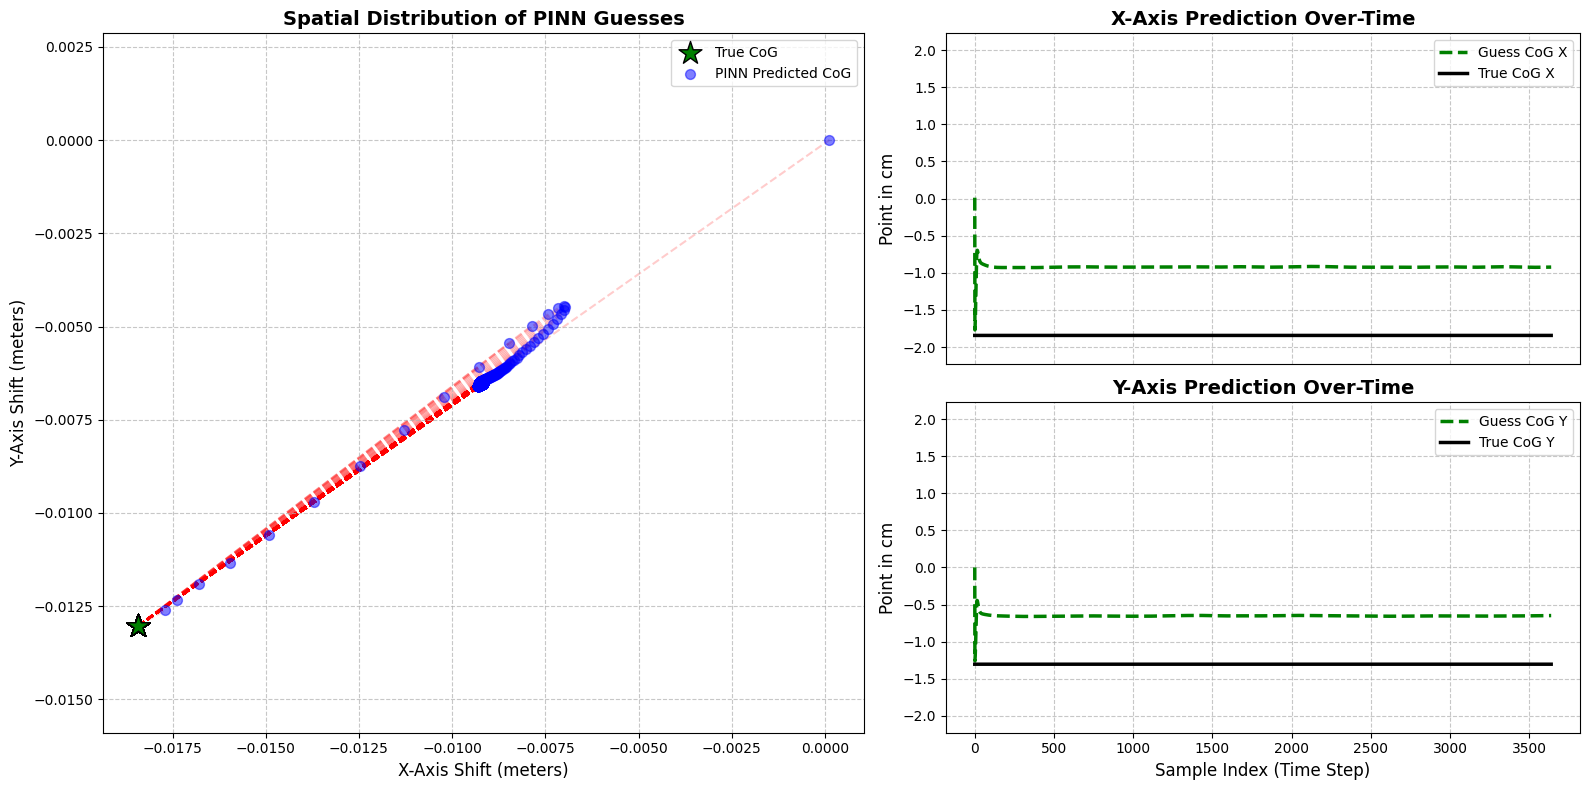

In [15]:
error_x_cm = (df_filtered["guess_cog_x"] - df_filtered["true_cog_x"]) * 100
error_y_cm = (df_filtered["guess_cog_y"] - df_filtered["true_cog_y"]) * 100

cog_guess_x_cm = df_filtered["guess_cog_x"] * 100
cog_guess_y_cm = df_filtered["guess_cog_y"] * 100

cog_true_x_cm = df_filtered["true_cog_x"] * 100
cog_true_y_cm = df_filtered["true_cog_y"] * 100

# ==========================================
# FIGURE SETUP (GridSpec Layout)
# ==========================================
# Create a 16x8 inch figure. 
fig = plt.figure(figsize=(16, 8))

# Create a 2x2 grid. 
gs = GridSpec(2, 2, figure=fig, width_ratios=[1.2, 1])

# Assign subplots to the grid
ax_scatter = fig.add_subplot(gs[:, 0]) # Left column, spans both rows
ax_err_x = fig.add_subplot(gs[0, 1])   # Right column, top row
ax_err_y = fig.add_subplot(gs[1, 1])   # Right column, bottom row

# ==========================================
# SUBPLOT 1: The Spatial Scatter Plot
# ==========================================
ax_scatter.scatter(df_filtered["true_cog_x"], df_filtered["true_cog_y"], 
            color='green', marker='*', s=300, edgecolor='black', label='True CoG', zorder=3)

ax_scatter.scatter(df_filtered["guess_cog_x"], df_filtered["guess_cog_y"], 
            color='blue', marker='o', s=50, alpha=0.5, label='PINN Predicted CoG', zorder=2)

for i in range(len(df_filtered)):
    ax_scatter.plot([df_filtered["true_cog_x"].iloc[i], df_filtered["guess_cog_x"].iloc[i]], 
             [df_filtered["true_cog_y"].iloc[i], df_filtered["guess_cog_y"].iloc[i]], 
             color='red', linestyle='--', alpha=0.2, zorder=1)

ax_scatter.set_title('Spatial Distribution of PINN Guesses', fontsize=14, fontweight='bold')
ax_scatter.set_xlabel('X-Axis Shift (meters)', fontsize=12)
ax_scatter.set_ylabel('Y-Axis Shift (meters)', fontsize=12)
ax_scatter.axis('equal') 
ax_scatter.grid(True, linestyle='--', alpha=0.7)
ax_scatter.legend(fontsize=10, loc='upper right')

# ==========================================
# SUBPLOT 2: X-Axis Error Timeline
# ==========================================
time_steps = range(len(df_filtered))

ax_err_x.plot(time_steps, cog_guess_x_cm, 
         color='green', linewidth=2.5, linestyle='--', label='Guess CoG X')

# true line
ax_err_x.plot(time_steps, cog_true_x_cm, 
         color='black', linewidth=2.5, label='True CoG X')

ax_err_x.set_title('X-Axis Prediction Over-Time', fontsize=14, fontweight='bold')
ax_err_x.set_ylabel('Point in cm', fontsize=12)
# Hide X-ticks for the top plot so it looks cleaner
ax_err_x.tick_params(axis='x', which='both', bottom=False, labelbottom=False) 
ax_err_x.grid(True, linestyle='--', alpha=0.7)
ax_err_x.legend(fontsize=10, loc='upper right')

# ==========================================
# SUBPLOT 3: Y-Axis Error Timeline
# ==========================================
ax_err_y.plot(time_steps, cog_guess_y_cm, 
         color='green', linewidth=2.5, linestyle='--', label='Guess CoG Y')

# true line
ax_err_y.plot(time_steps, cog_true_y_cm, 
         color='black', linewidth=2.5, label='True CoG Y')

ax_err_y.set_title('Y-Axis Prediction Over-Time', fontsize=14, fontweight='bold')
ax_err_y.set_xlabel('Sample Index (Time Step)', fontsize=12)
ax_err_y.set_ylabel('Point in cm', fontsize=12)
ax_err_y.grid(True, linestyle='--', alpha=0.7)
ax_err_y.legend(fontsize=10, loc='upper right')

# ==========================================
# FINAL FORMATTING & SAVE
# ==========================================
# Sync the Y-axis scales for the error plots so they are visually comparable
max_err = max(abs(error_x_cm).max(), abs(error_y_cm).max()) * 1.2
ax_err_x.set_ylim(-max_err, max_err)
ax_err_y.set_ylim(-max_err, max_err)

plt.tight_layout() 
plt.savefig('cog_axis_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

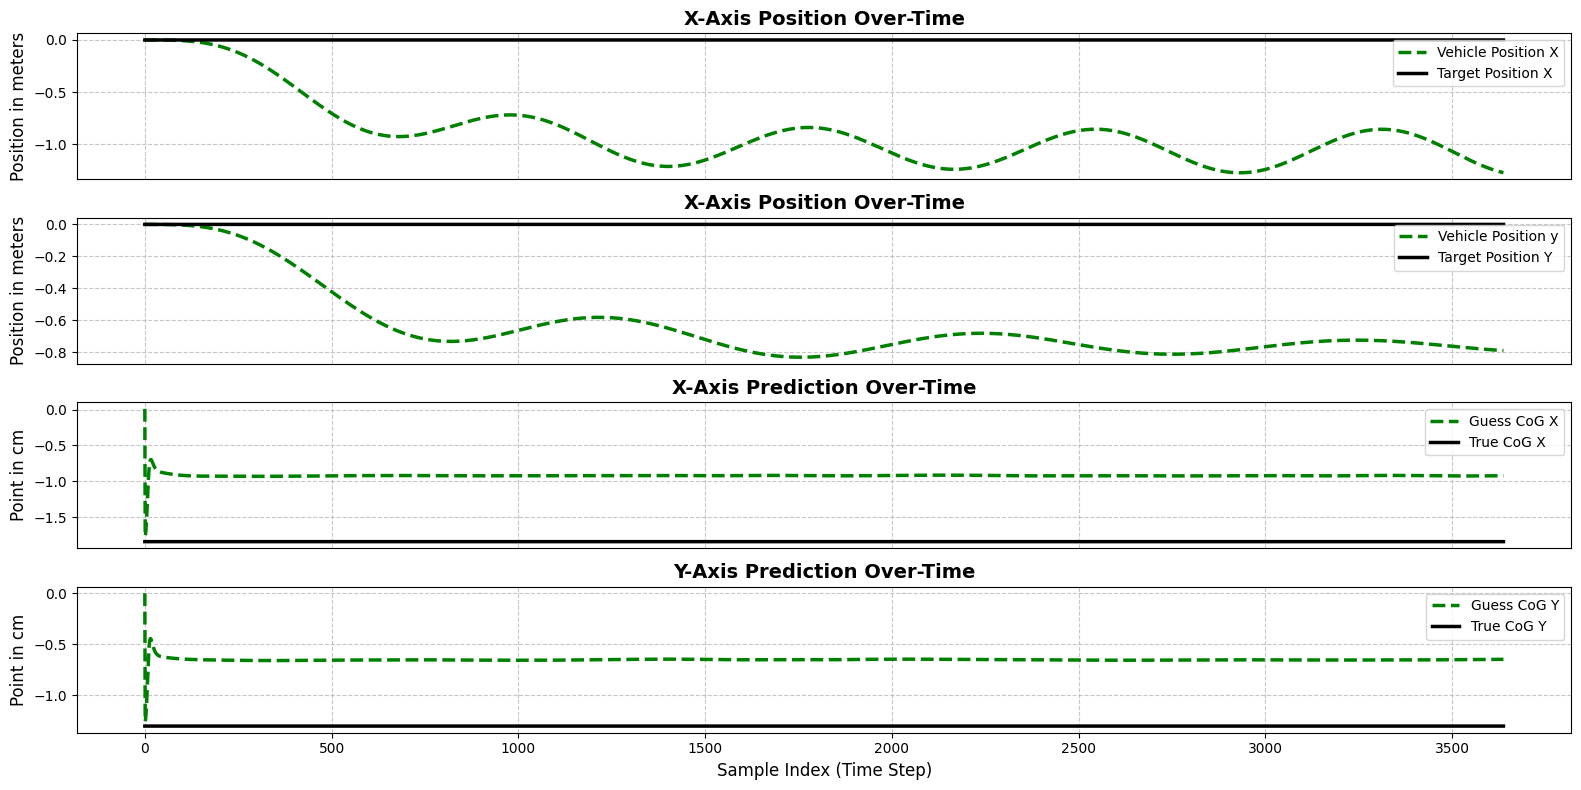

In [ ]:
fig = plt.figure(figsize=(16, 8))

time_steps = range(len(df_filtered))

# Create a 2x2 grid. 
gs = GridSpec(4, 1, figure=fig, width_ratios=[1.2])

# position over-time
ax_pos_x = fig.add_subplot(gs[0, 0])   # Right column, top row

ax_pos_x.plot(time_steps, df_filtered["pos_x"], 
         color='green', linewidth=2.5, linestyle='--', label='Vehicle Position X')

# true line
ax_pos_x.plot(time_steps, df_filtered["target_pos_x"], 
         color='black', linewidth=2.5, label='Target Position X')

ax_pos_x.set_title('X-Axis Position Over-Time', fontsize=14, fontweight='bold')
ax_pos_x.set_ylabel('Position in meters', fontsize=12)
# Hide X-ticks for the top plot so it looks cleaner
ax_pos_x.tick_params(axis='x', which='both', bottom=False, labelbottom=False) 
ax_pos_x.grid(True, linestyle='--', alpha=0.7)
ax_pos_x.legend(fontsize=10, loc='upper right')


ax_pos_y = fig.add_subplot(gs[1, 0])   # Right column, top row

ax_pos_y.plot(time_steps, df_filtered["pos_y"], 
         color='green', linewidth=2.5, linestyle='--', label='Vehicle Position y')

# true line
ax_pos_y.plot(time_steps, df_filtered["target_pos_y"], 
         color='black', linewidth=2.5, label='Target Position Y')

ax_pos_y.set_title('X-Axis Position Over-Time', fontsize=14, fontweight='bold')
ax_pos_y.set_ylabel('Position in meters', fontsize=12)
# Hide X-ticks for the top plot so it looks cleaner
ax_pos_y.tick_params(axis='x', which='both', bottom=False, labelbottom=False) 
ax_pos_y.grid(True, linestyle='--', alpha=0.7)
ax_pos_y.legend(fontsize=10, loc='upper right')

# CoG Guess over-time
ax_cog_guess_x = fig.add_subplot(gs[2, 0])   # Right column, top row

ax_cog_guess_x.plot(time_steps, cog_guess_x_cm, 
         color='green', linewidth=2.5, linestyle='--', label='Guess CoG X')

# true line
ax_cog_guess_x.plot(time_steps, cog_true_x_cm, 
         color='black', linewidth=2.5, label='True CoG X')

ax_cog_guess_x.set_title('X-Axis CoG Prediction Over-Time', fontsize=14, fontweight='bold')
ax_cog_guess_x.set_ylabel('Point in cm', fontsize=12)
# Hide X-ticks for the top plot so it looks cleaner
ax_cog_guess_x.tick_params(axis='x', which='both', bottom=False, labelbottom=False) 
ax_cog_guess_x.grid(True, linestyle='--', alpha=0.7)
ax_cog_guess_x.legend(fontsize=10, loc='upper right')


ax_cog_guess_y = fig.add_subplot(gs[3, 0])   # Right column, top row

ax_cog_guess_y.plot(time_steps, cog_guess_y_cm, 
         color='green', linewidth=2.5, linestyle='--', label='Guess CoG Y')

# true line
ax_cog_guess_y.plot(time_steps, cog_true_y_cm, 
         color='black', linewidth=2.5, label='True CoG Y')

ax_cog_guess_y.set_title('Y-Axis CoG Prediction Over-Time', fontsize=14, fontweight='bold')
ax_cog_guess_y.set_xlabel('Sample Index (Time Step)', fontsize=12)
ax_cog_guess_y.set_ylabel('Point in cm', fontsize=12)
ax_cog_guess_y.grid(True, linestyle='--', alpha=0.7)
ax_cog_guess_y.legend(fontsize=10, loc='upper right')

plt.tight_layout()
plt.show()

In [9]:
df = pd.read_csv("hover_geo_flight_data_100ep_1.csv")
df.describe()

,episode_num,time_t,pos_x,pos_y,pos_z,roll,pitch,yaw,velocity_x,velocity_y,...,thrust_3,thrust_4,wrench_thrust,wrench_roll,wrench_pitch,wrench_yaw,guess_cog_x,guess_cog_y,true_cog_x,true_cog_y
count,362936.000000,362936.000000,362936.000000,362936.000000,362936.000000,362936.000000,362936.000000,362936.000000,362936.000000,362936.000000,...,362936.000000,362936.000000,362936.000000,362936.000000,362936.000000,362936.000000,362936.000000,362936.000000,362936.000000,362936.000000
mean,57.276456,9.233560,-0.097671,0.009862,4.430397,0.000603,0.000509,0.000037,0.000982,-0.007076,...,19.319133,19.314679,76.968295,-0.001506,-0.001407,0.000016,-0.001972,0.000085,-0.001972,0.000085
std,34.122166,6.036781,0.414361,0.429862,2.149197,0.019629,0.018738,0.000617,0.181565,0.187654,...,0.641521,0.641447,1.794409,0.128221,0.122143,0.000662,0.008421,0.008362,0.008421,0.008362
min,0.000000,0.000000,-1.483162,-1.488398,0.195466,-0.103963,-0.110749,-0.003559,-1.183239,-1.193762,...,17.455886,17.708871,74.104313,-1.754928,-1.878938,-0.005796,-0.019125,-0.019060,-0.019125,-0.019060
25%,29.000000,3.595833,-0.362432,-0.172412,2.521059,-0.002770,-0.002963,-0.000121,-0.019521,-0.018128,...,18.885461,18.879641,76.457156,-0.015300,-0.015162,-0.000132,-0.009310,-0.006202,-0.009310,-0.006202
50%,55.000000,9.029167,-0.023307,-0.000172,5.902421,0.000018,-0.000018,-0.000001,-0.000300,-0.000286,...,19.302362,19.260523,76.626693,-0.000063,0.000040,0.000003,-0.001311,0.000519,-0.001311,0.000519
75%,85.000000,14.508333,0.050823,0.126591,5.975758,0.003074,0.002980,0.000250,0.018082,0.016930,...,19.661844,19.665094,77.734659,0.014389,0.014791,0.000129,0.004017,0.005766,0.004017,0.005766
max,120.000000,20.000000,1.498987,1.498832,6.155405,0.112332,0.106942,0.005690,1.134289,1.107589,...,25.793043,25.527916,97.977601,1.980181,1.881047,0.006581,0.019136,0.018089,0.019136,0.018089


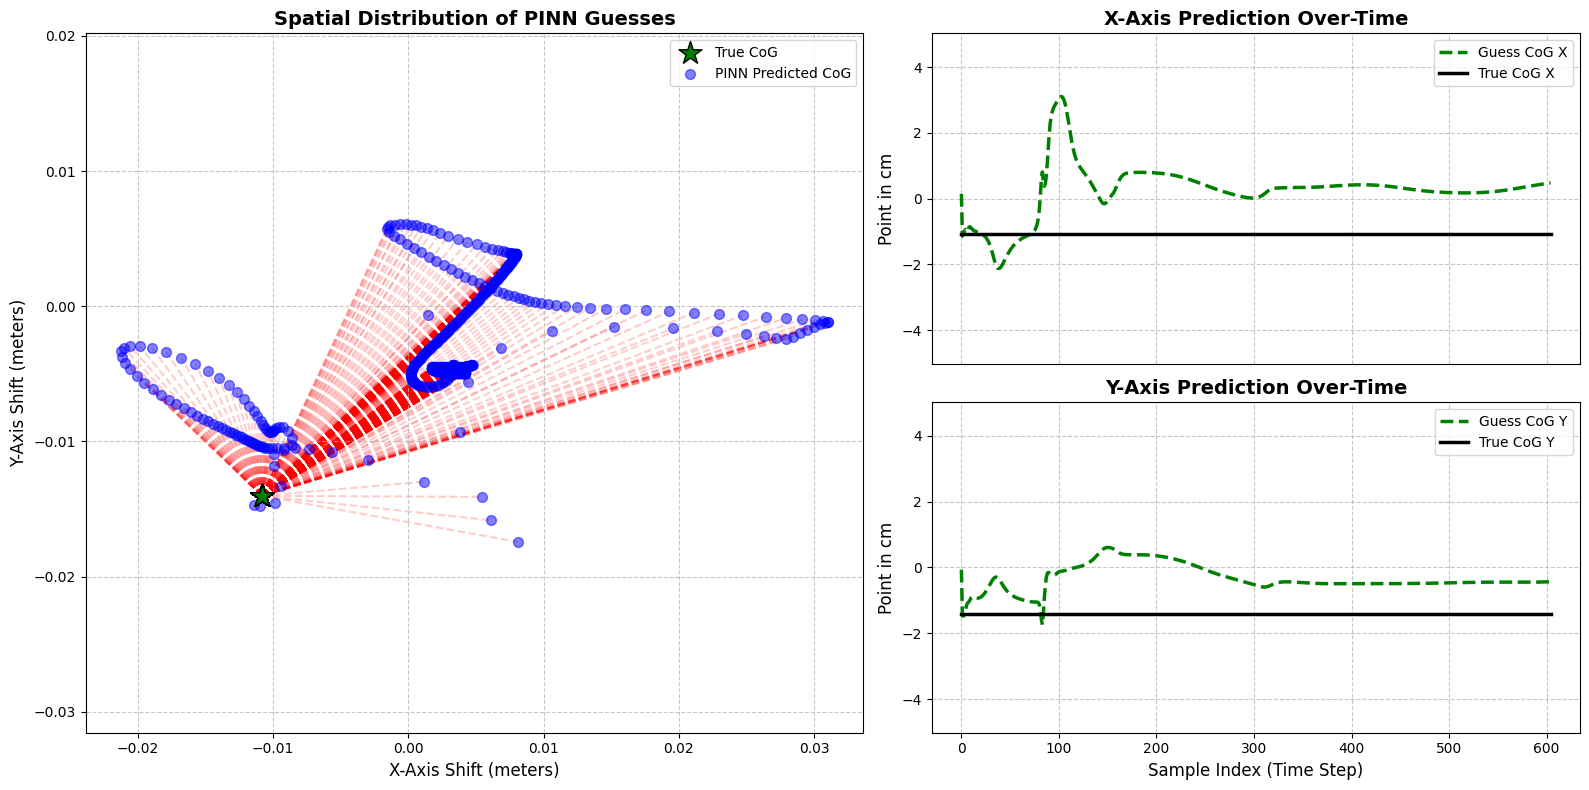

In [8]:

df_validation = pd.read_csv("hover_geo_inference_flight_data_100ep.csv")
df_validation.head()

df_filtered = df_validation[df_validation["episode_num"] == 10]

error_x_cm = (df_filtered["guess_cog_x"] - df_filtered["true_cog_x"]) * 100
error_y_cm = (df_filtered["guess_cog_y"] - df_filtered["true_cog_y"]) * 100

cog_guess_x_cm = df_filtered["guess_cog_x"] * 100
cog_guess_y_cm = df_filtered["guess_cog_y"] * 100

cog_true_x_cm = df_filtered["true_cog_x"] * 100
cog_true_y_cm = df_filtered["true_cog_y"] * 100

# ==========================================
# FIGURE SETUP (GridSpec Layout)
# ==========================================
# Create a 16x8 inch figure. 
fig = plt.figure(figsize=(16, 8))

# Create a 2x2 grid. 
gs = GridSpec(2, 2, figure=fig, width_ratios=[1.2, 1])

# Assign subplots to the grid
ax_scatter = fig.add_subplot(gs[:, 0]) # Left column, spans both rows
ax_err_x = fig.add_subplot(gs[0, 1])   # Right column, top row
ax_err_y = fig.add_subplot(gs[1, 1])   # Right column, bottom row

# ==========================================
# SUBPLOT 1: The Spatial Scatter Plot
# ==========================================
ax_scatter.scatter(df_filtered["true_cog_x"], df_filtered["true_cog_y"], 
            color='green', marker='*', s=300, edgecolor='black', label='True CoG', zorder=3)

ax_scatter.scatter(df_filtered["guess_cog_x"], df_filtered["guess_cog_y"], 
            color='blue', marker='o', s=50, alpha=0.5, label='PINN Predicted CoG', zorder=2)

for i in range(len(df_filtered)):
    ax_scatter.plot([df_filtered["true_cog_x"].iloc[i], df_filtered["guess_cog_x"].iloc[i]], 
             [df_filtered["true_cog_y"].iloc[i], df_filtered["guess_cog_y"].iloc[i]], 
             color='red', linestyle='--', alpha=0.2, zorder=1)

ax_scatter.set_title('Spatial Distribution of PINN Guesses', fontsize=14, fontweight='bold')
ax_scatter.set_xlabel('X-Axis Shift (meters)', fontsize=12)
ax_scatter.set_ylabel('Y-Axis Shift (meters)', fontsize=12)
ax_scatter.axis('equal') 
ax_scatter.grid(True, linestyle='--', alpha=0.7)
ax_scatter.legend(fontsize=10, loc='upper right')

# ==========================================
# SUBPLOT 2: X-Axis Error Timeline
# ==========================================
time_steps = range(len(df_filtered))

ax_err_x.plot(time_steps, cog_guess_x_cm, 
         color='green', linewidth=2.5, linestyle='--', label='Guess CoG X')

# true line
ax_err_x.plot(time_steps, cog_true_x_cm, 
         color='black', linewidth=2.5, label='True CoG X')

ax_err_x.set_title('X-Axis Prediction Over-Time', fontsize=14, fontweight='bold')
ax_err_x.set_ylabel('Point in cm', fontsize=12)
# Hide X-ticks for the top plot so it looks cleaner
ax_err_x.tick_params(axis='x', which='both', bottom=False, labelbottom=False) 
ax_err_x.grid(True, linestyle='--', alpha=0.7)
ax_err_x.legend(fontsize=10, loc='upper right')

# ==========================================
# SUBPLOT 3: Y-Axis Error Timeline
# ==========================================
ax_err_y.plot(time_steps, cog_guess_y_cm, 
         color='green', linewidth=2.5, linestyle='--', label='Guess CoG Y')

# true line
ax_err_y.plot(time_steps, cog_true_y_cm, 
         color='black', linewidth=2.5, label='True CoG Y')

ax_err_y.set_title('Y-Axis Prediction Over-Time', fontsize=14, fontweight='bold')
ax_err_y.set_xlabel('Sample Index (Time Step)', fontsize=12)
ax_err_y.set_ylabel('Point in cm', fontsize=12)
ax_err_y.grid(True, linestyle='--', alpha=0.7)
ax_err_y.legend(fontsize=10, loc='upper right')

# ==========================================
# FINAL FORMATTING & SAVE
# ==========================================
# Sync the Y-axis scales for the error plots so they are visually comparable
max_err = max(abs(error_x_cm).max(), abs(error_y_cm).max()) * 1.2
ax_err_x.set_ylim(-max_err, max_err)
ax_err_y.set_ylim(-max_err, max_err)

plt.tight_layout() 
plt.savefig('cog_axis_analysis.png', dpi=300, bbox_inches='tight')
plt.show()